# Procesos Autorregresivos (AR)

## Introducción a las Series Temporales y Procesos AR

### ¿Qué era eso de una Serie Temporal?

Una serie temporal es una colección de observaciones hechas secuencialmente a lo largo del tiempo. Ejemplos comunes incluyen temperaturas diarias, precios de acciones, ventas mensuales, etc.

### ¿Qué es un Proceso Autorregresivo (AR)?

Un proceso autorregresivo de orden p, denotado como AR(p), es un modelo que utiliza observaciones pasadas de la serie para predecir valores futuros. La ecuación general de un modelo AR(p) es:

$y[t] = c + φ_1 * y[t-1] + φ_2 * y[t-2] + ... + φ_p * y[t-p] + ε[t]$

- y[t]: Valor de la serie en el tiempo t.
- c: Constante o término de intercepto.
- φ1, φ2, ..., φp: Coeficientes del modelo.
- y[t-1], y[t-2], ..., y[t-p]: Valores pasados de la serie.
- ε[t]: Término de error o ruido blanco, con media cero y varianza constante.

## Importancia de los Modelos AR

Los modelos AR son fundamentales en el análisis de series temporales porque:
- Permiten capturar patrones temporales en los datos.
- Son fáciles de interpretar y aplicar.
- Pueden ser utilizados para hacer predicciones futuras.
- Son la base para modelos más complejos como ARMA y ARIMA.

## Implementación en Python

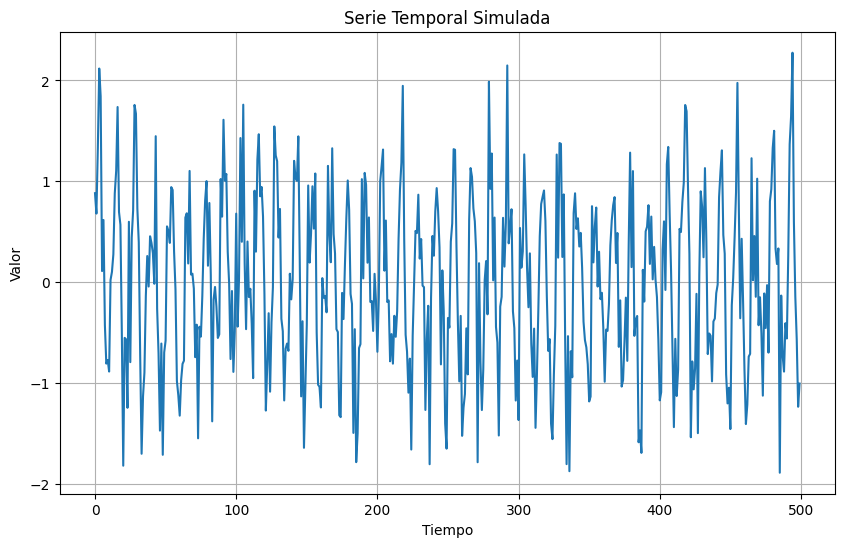

In [10]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Generar una serie temporal simulada
np.random.seed(0)
time = np.arange(0, 500, 1)
# series = np.sin(time * 0.1) + np.random.normal(0, 0.1, len(time))
series = np.sin(time * 0.5) + np.random.normal(0, 0.5, len(time))

# Visualizar la serie
df = pd.DataFrame({'Value': series})
plt.figure(figsize=(10, 6))
plt.plot(df['Value'])
plt.title('Serie Temporal Simulada')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.grid(True)
plt.show()

### Explicación del Código
- **Generación de la serie temporal**: Creamos una serie de tiempo simulada que combina una función senoidal y ruido aleatorio.
- **Visualización**: Usamos matplotlib para graficar la serie y observar su comportamiento.

In [11]:
# Ajustar un modelo AR(1)
model = AutoReg(df['Value'], lags=1)
model_fit = model.fit()

# Resumen del modelo
print(model_fit.summary())

# Predecir valores
predictions = model_fit.predict(start=len(df), end=len(df))
print(f'Predicción para el siguiente paso: {predictions.iloc[-1]}')
df.tail()


                            AutoReg Model Results                             
Dep. Variable:                  Value   No. Observations:                  500
Model:                     AutoReg(1)   Log Likelihood                -528.151
Method:               Conditional MLE   S.D. of innovations              0.697
Date:                Thu, 12 Feb 2026   AIC                           1062.303
Time:                        20:34:31   BIC                           1074.940
Sample:                             1   HQIC                          1067.262
                                  500                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0067      0.031     -0.213      0.831      -0.068       0.055
Value.L1       0.5734      0.037     15.628      0.000       0.501       0.645
                                    Roots           

,Value
495,0.596345
496,-0.144524
497,-0.566154
498,-1.236184
499,-1.006182


### Explicación del Código

- **Ajuste del modelo AR(1)**: Usamos AutoReg de statsmodels para ajustar un modelo AR(1) a nuestra serie temporal.
- **Resumen del modelo**: Imprimimos un resumen estadístico del modelo ajustado, que incluye coeficientes, errores estándar, valores p, etc.
   - **Coeficientes del modelo**:
        - **coef**: Valor estimado del término.
        - **std err**: Error estándar del coeficiente estimado.
        - **z**: Estadístico z, que es el coeficiente dividido por su error estándar.
        - **P > |z|**: Valor p asociado al estadístico z. Un valor p bajo (generalmente < 0.05) indica que el coeficiente es estadísticamente significativo.
        - **[0.025 | 0.975]**: Intervalo de confianza del 95% para el coeficiente.
    - **Raíces del polinomio característico (Roots)**:
        - Nos indican si el modelo es estacionario siempre que el módulo sea superior a uno (si tiene raíces complejas igual pero haciendo el módulo complejo).
        - **¿Qué significa que sea estacionario?**
            - Las propiedades estadísticas del modelo (media, varianza, autocorrelación) no cambian con el tiempo.
            - Las predicciones del modelo son estables y no divergen a infinito.
        - **¿Es estacionario lo mismo que estacional?**: No. Estacionario se refiere a la estabilidad del modelo de autorregresión, estacional se refiere a la estacionalidad de los datos de la serie (si hay algún factor estacional que influya en los datos). 


- **Predicción**: Realizamos una predicción para el siguiente valor en la serie temporal.

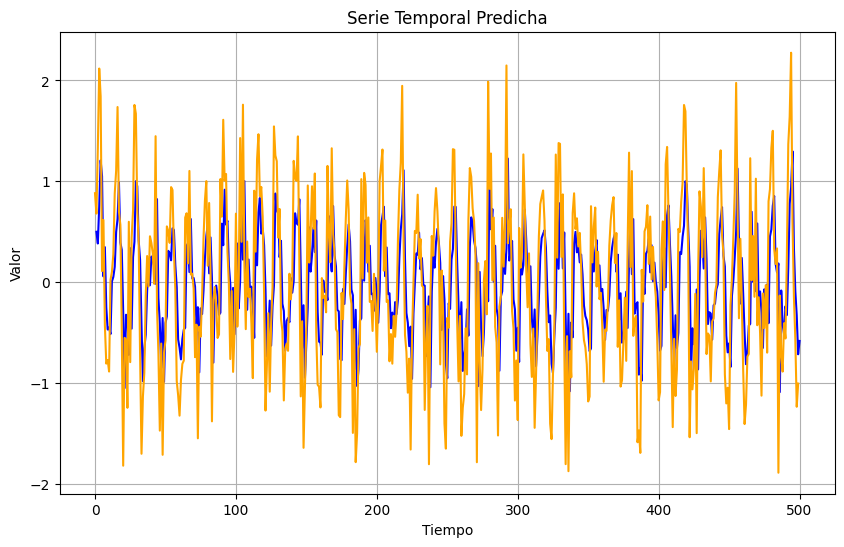

In [12]:
# Predecir valores para toda la serie
predictions = model_fit.predict(start=1, end=len(df))

plt.figure(figsize=(10, 6))
plt.plot(predictions, color="blue" )
plt.plot(df['Value'], color = "orange")
plt.title('Serie Temporal Predicha')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.grid(True)
plt.show()

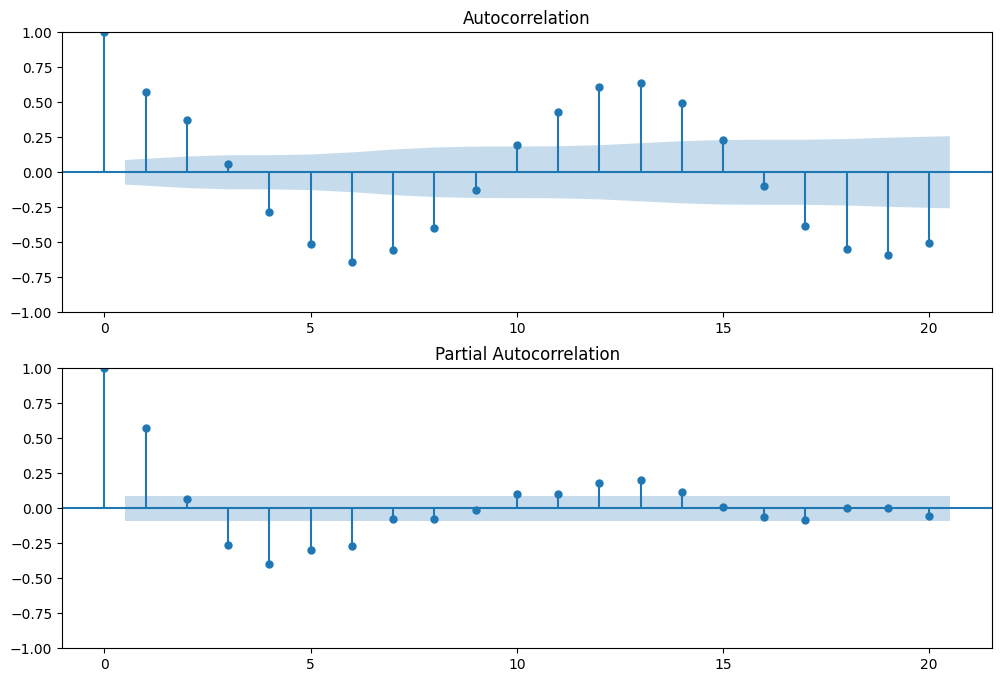

In [13]:
# Visualizar la función de autocorrelación (ACF) y autocorrelación parcial (PACF)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['Value'], lags=20, ax=ax1)
plot_pacf(df['Value'], lags=20, ax=ax2)
plt.show()

### Explicación de ACF y PACF
- **ACF (Autocorrelation Function)**: Mide la correlación entre la serie y sus valores rezagados. Es útil para identificar patrones en los datos.
- **PACF (Partial Autocorrelation Function)**: Mide la correlación entre la serie y sus valores rezagados, eliminando el efecto de los rezagos intermedios. Es útil para identificar el orden p en modelos AR.

### Interpretación de los Gráficos de ACF y PACF
#### ACF

- Si la ACF muestra picos significativos en rezagos específicos, puede indicar estacionalidad.
- Si la ACF decae lentamente, sugiere que la serie tiene una componente autorregresiva (AR).
- Si la ACF corta abruptamente después de un rezago q, sugiere un modelo MA(q).
#### PACF

- Si la PACF corta abruptamente después de un rezago p, sugiere un modelo AR(p).
- Si la PACF decae lentamente, sugiere que la serie tiene una componente de media móvil (MA).


## Explicación Teórica Adicional

### Selección del Orden del Modelo

Para seleccionar el orden p de un modelo AR, se suele observar el gráfico PACF y buscar el punto donde los valores de PACF cortan el intervalo de confianza. Este punto indica el número de rezagos significativos.
